In [8]:
# ============================================================================
# 1. ÖN İŞLENMİŞ VERİLERİN HAFIZAYA YÜKLENMESİ
# ============================================================================
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Grafik tasarımları
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')

print("⏳ 'processed_data/' klasöründeki matrisler yükleniyor...")
X_train = joblib.load('processed_data/X_train_normalized.pkl')
X_test = joblib.load('processed_data/X_test_normalized.pkl')
y_train = joblib.load('processed_data/y_train.pkl')
y_test = joblib.load('processed_data/y_test.pkl')

print(f"✅ Veriler Eğitime Hazır!")
print(f"   - Eğitim Özellik Matrisi: {X_train.shape}")
print(f"   - Test Özellik Matrisi:   {X_test.shape}")

⏳ 'processed_data/' klasöründeki matrisler yükleniyor...
✅ Veriler Eğitime Hazır!
   - Eğitim Özellik Matrisi: (12000, 129)
   - Test Özellik Matrisi:   (3000, 129)


In [9]:
# ============================================================================
# 2. MODELLERİN EĞİTİLMESİ VE PERFORMANS ÖLÇÜMÜ
# ============================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Modelleri sözlük yapısında tanımlayalım
modeller = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

sonuclar = []

# Döngüyle modelleri sırayla eğitelim
for model_adi, model in modeller.items():
    print(f"🚀 {model_adi} eğitiliyor...")
    model.fit(X_train, y_train)
    
    # Test seti üzerinde tahmin yapalım
    tahminler = model.predict(X_test)
    
    # Metrikleri hesaplayalım
    acc = accuracy_score(y_test, tahminler)
    prec = precision_score(y_test, tahminler)
    rec = recall_score(y_test, tahminler)
    f1 = f1_score(y_test, tahminler)
    
    sonuclar.append({
        "Model": model_adi,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })

# Sonuçları şık bir Pandas tablosuna dönüştürelim
sonuc_df = pd.DataFrame(sonuclar)
print("\n📊 MODELLERİN KARŞILAŞTIRMA TABLOSU:")
print(sonuc_df.round(4).to_string(index=False))

🚀 Logistic Regression eğitiliyor...
🚀 Random Forest eğitiliyor...

📊 MODELLERİN KARŞILAŞTIRMA TABLOSU:
              Model  Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.7640     1.0000   0.292    0.4520
      Random Forest    0.7947     0.7157   0.637    0.6741


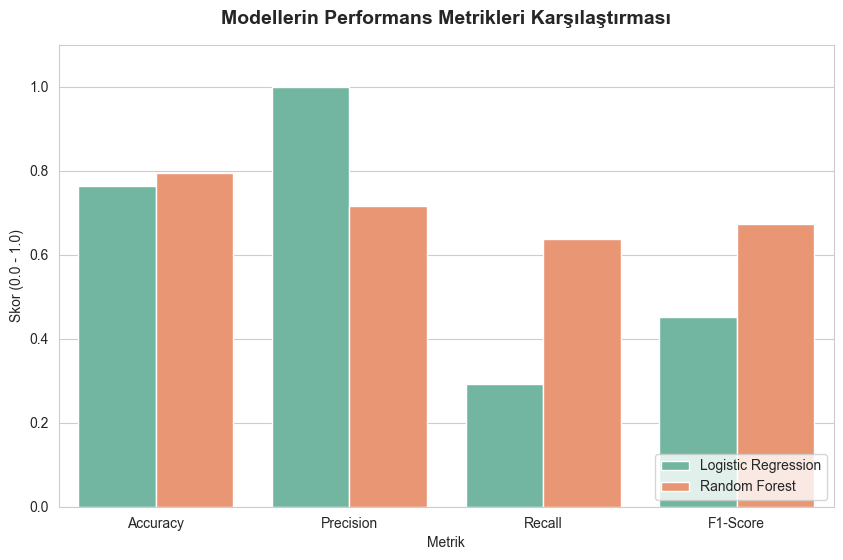

In [10]:
# ============================================================================
# 3. MODEL PERFORMANSLARININ GÖRSELLEŞTİRİLMESİ
# ============================================================================
# Tabloyu grafik formatına uygun hale getirelim (Melt işlemi)
melted_df = pd.melt(sonuc_df, id_vars="Model", var_name="Metrik", value_name="Skor")

plt.figure(figsize=(10, 6))
sns.barplot(x="Metrik", y="Skor", hue="Model", data=melted_df, palette="Set2")
plt.title("Modellerin Performans Metrikleri Karşılaştırması", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("Skor (0.0 - 1.0)")
plt.ylim(0, 1.1)
plt.legend(loc="lower right")
plt.show()

In [11]:
# ============================================================================
# 4. HİPERPARAMETRE OPTİMİZASYONU (GRID SEARCH)
# ============================================================================
from sklearn.model_selection import GridSearchCV

print("⚙️ En iyi model için hiperparametre araması başlatılıyor...")

# Denenecek parametre havuzu
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20]
}

# Random Forest üzerinde 3 katmanlı çapraz doğrulama (cv=3) ile arayalım
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"\n🎯 En İyi Parametreler: {grid_search.best_params_}")
print(f"🏆 En İyi Eğitim Doğruluğu: % {grid_search.best_score_ * 100:.2f}")

# En iyi modeli test setinde deneyelim
en_iyi_model = grid_search.best_estimator_
final_tahmin = en_iyi_model.predict(X_test)
print(f"⚡ Optimize Edilmiş Modelin Test Doğruluğu: % {accuracy_score(y_test, final_tahmin) * 100:.2f}")

⚙️ En iyi model için hiperparametre araması başlatılıyor...

🎯 En İyi Parametreler: {'max_depth': 10, 'n_estimators': 100}
🏆 En İyi Eğitim Doğruluğu: % 88.30
⚡ Optimize Edilmiş Modelin Test Doğruluğu: % 87.90


In [12]:
# ============================================================================
# 5. NİHAİ OPTİMİZE MODELİN DİSKE KAYDEDİLMESİ
# ============================================================================
# Projenin ana klasörüne kaydediyoruz ki chatbot dosyan (app.py) rahatça okusun
joblib.dump(en_iyi_model, 'yapay_zeka_modeli.pkl')

print("💾 Optimize edilmiş en iyi model 'yapay_zeka_modeli.pkl' olarak başarıyla kaydedildi!")

💾 Optimize edilmiş en iyi model 'yapay_zeka_modeli.pkl' olarak başarıyla kaydedildi!
